In [1]:
import numpy as np
import torch
import scipy.stats
from math import sqrt
import pickle, yaml, os, time, argparse
from pathlib import Path
import matplotlib.pyplot as plt

In [9]:
trajectories_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/data/"
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/pmmh/"

experiment_ID = 1
posterior_samples_config_path = results_path + f"posterior_samples{experiment_ID}.yaml"
posterior_samples_path = results_path + f"posterior_samples{experiment_ID}.npz"

with open(posterior_samples_config_path, "r") as f:
    posterior_samples_config = yaml.safe_load(f)

posterior_samples_dict = np.load(posterior_samples_path)

In [10]:
# Assign variables
x_observed_ID = posterior_samples_config["x_observed_ID"]
total_time = posterior_samples_config["total_time"]
sigma2_alpha = posterior_samples_config["sigma2_alpha"]
sigma2_beta = posterior_samples_config["sigma2_beta"]
beta2_alpha = posterior_samples_config["beta2_alpha"]
beta2_beta = posterior_samples_config["beta2_beta"]
rho_lower = posterior_samples_config["rho_lower"]
rho_upper = posterior_samples_config["rho_upper"]
T = posterior_samples_config["T"]
initial_distribution_variance = posterior_samples_config["initial_distribution_variance"]
num_iterations = posterior_samples_config["num_iterations"]
N = posterior_samples_config["N"]
step_sizes = posterior_samples_config["step_sizes"]
theta_0 = posterior_samples_config["theta_0"]
sample_trajectories = posterior_samples_config["sample_trajectories"]
print_ks = posterior_samples_config["print_ks"]

In [11]:
trajectory_path = trajectories_path + f"trajectory{x_observed_ID}.npz"
trajectory_config_path = trajectories_path + f"trajectory{x_observed_ID}.yaml"

trajectory = np.load(trajectory_path)
with open(trajectory_config_path, "r") as f:
    trajectory_config = yaml.safe_load(f)

In [12]:
z = trajectory["z"][: T+1]
x_observed = trajectory["x"][: T+1]

beta2_true = trajectory_config["beta2_true"]
beta_true = trajectory_config["beta_true"]
initial_distribution_variance = trajectory_config["initial_distribution_variance"]
rho_true = trajectory_config["rho_true"]
sigma2_true = trajectory_config["sigma2_true"]
sigma_true = trajectory_config["sigma_true"]

In [13]:
thetas = posterior_samples_dict["thetas"]
loglikelihoods = posterior_samples_dict["loglikelihoods"]
acceptance_ratios = posterior_samples_dict["acceptance_ratios"]
if sample_trajectories:
    z_0_to_Ts = posterior_samples_dict["z_0_to_Ts"]




sigma2_samples = thetas[:, 0]
beta2_samples = thetas[:, 1]
rho_samples = thetas[:, 2]
z_0_to_T_samples = z_0_to_Ts

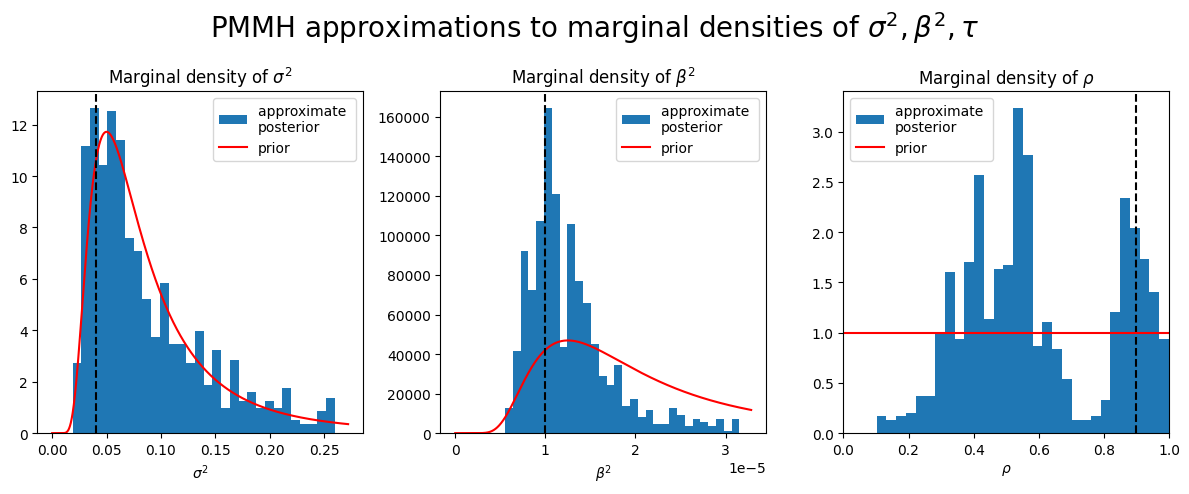

In [14]:
fig, ax = plt.subplots(figsize=(12,5), ncols=3)
bins=30

ax[0].hist(sigma2_samples, bins=bins, density=True, label="approximate \nposterior")
xl, xu = ax[0].get_xlim()
ax[0].plot(np.linspace(0,xu,1000), 
           scipy.stats.invgamma.pdf(np.linspace(0,xu,1000), a=sigma2_alpha, scale=sigma2_beta),
           color="red", label=r"prior")
ax[0].axvline(sigma2_true, color="k", linestyle="--")
ax[0].set_xlabel(r"$\sigma^2$")
ax[0].set_title(r"Marginal density of $\sigma^2$")
ax[0].legend()

ax[1].hist(beta2_samples, bins=bins, density=True, label="approximate \nposterior")
xl, xu = ax[1].get_xlim()
ax[1].plot(np.linspace(0,xu,1000), 
           scipy.stats.invgamma.pdf(np.linspace(0,xu,1000), a=beta2_alpha, scale=beta2_beta),
           color="red", label=r"prior")
ax[1].axvline(beta2_true, color="k", linestyle="--")
ax[1].set_xlabel(r"$\beta^2$")
ax[1].set_title(r"Marginal density of $\beta^2$")
ax[1].legend()

ax[2].set_xlim(rho_lower, rho_upper)
ax[2].hist(rho_samples, bins=bins, density=True, label="approximate \nposterior")
ax[2].axvline(rho_true, color="k", linestyle="--")
ax[2].axhline(1/(rho_upper - rho_lower), xmin=rho_lower, xmax=rho_upper, color="red", label=r"prior")
ax[2].set_xlabel(r"$\rho$")
ax[2].set_title(r"Marginal density of $\rho$")
ax[2].legend()

plt.suptitle(r"PMMH approximations to marginal densities of $\sigma^2, \beta^2, \tau$", fontsize=20)
plt.tight_layout()
plt.show()